# 🔮 LaporKeuangan — Head 2: Prediksi Arus Kas
## SnapBudget · CC26-PSU098 · Coding Camp 2026 · DBS Foundation

**Tujuan Notebook ini:**
Head 2 bertugas **memprediksi pengeluaran mahasiswa 7 hari ke depan**
berdasarkan riwayat transaksi 30 hari sebelumnya.

**Arsitektur Model:**
**8 Kategori:** makanan · minuman · transportasi · belanja · tagihan · hiburan · kesehatan · lain_lain

**Alur kerja:**
1. Install & import library
2. Generate dataset sintetis 150 user × 90 hari
3. Visualisasi & eksplorasi data (EDA)
4. Preprocessing & normalisasi
5. Bangun arsitektur model MLP + GRU
6. Training dengan custom loss & oversampling
7. Evaluasi performa model
8. Simpan model ke Google Drive
9. Inference: prediksi 7 hari ke depan

## ⚙️ Cell 1 — Install & Setup

Menginstall semua library yang dibutuhkan untuk membangun model prediksi.

- **`tensorflow`** → framework deep learning untuk membangun model GRU
- **`scikit-learn`** → untuk normalisasi data (MinMaxScaler) dan evaluasi metrik
- **`matplotlib`** → untuk visualisasi grafik training dan prediksi
- **`numpy`** → komputasi array dan operasi matematika
- **`pandas`** → manipulasi data tabular

> ⏳ Jalankan cell ini pertama kali saat membuka Colab baru.

In [ ]:
!pip install tensorflow scikit-learn matplotlib numpy pandas -q

print("✅ Instalasi selesai!")

✅ Instalasi selesai!


## 📦 Cell 2 — Import Library & Konfigurasi

Mengimport semua library dan mendefinisikan konfigurasi global yang akan
dipakai di seluruh notebook.

**Konfigurasi penting:**
- `CATEGORIES` → 8 kategori pengeluaran mahasiswa yang menjadi target prediksi
- `CAT_COLORS` → warna untuk setiap kategori (dipakai di semua visualisasi)
- `random seed` → dikunci ke 42 agar hasil training bisa direproduksi

> 💡 Seed yang sama memastikan setiap kali dijalankan, hasil training relatif sama.

In [ ]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

CATEGORIES = [
    'makanan', 'minuman', 'transportasi', 'belanja',
    'tagihan', 'hiburan', 'kesehatan', 'lain_lain'
]
N_CATS  = len(CATEGORIES)
CAT_IDX = {c: i for i, c in enumerate(CATEGORIES)}

CAT_COLORS = {
    'makanan'      : '#2ECC71',
    'minuman'      : '#3498DB',
    'transportasi' : '#E67E22',
    'belanja'      : '#9B59B6',
    'tagihan'      : '#E74C3C',
    'hiburan'      : '#F39C12',
    'kesehatan'    : '#1ABC9C',
    'lain_lain'    : '#95A5A6',
}

print(f"✅ Konfigurasi selesai!")
print(f"Kategori ({N_CATS}): {CATEGORIES}")
print(f"TF version: {tf.__version__}")

✅ Konfigurasi selesai!
Kategori (8): ['makanan', 'minuman', 'transportasi', 'belanja', 'tagihan', 'hiburan', 'kesehatan', 'lain_lain']
TF version: 2.20.0


## 🎲 Cell 3 — Generate Dataset Sintetis

Karena data transaksi mahasiswa nyata tidak tersedia, kita membuat **dataset sintetis**
yang merepresentasikan pola pengeluaran mahasiswa Indonesia.

**Cara kerja generator:**
Dataset dibuat untuk **150 user** selama **90 hari**, dengan pola realistis:

| Kategori | Pola |
|----------|------|
| Makanan | Harian, selalu ada |
| Minuman | Harian, 80% kemungkinan per hari |
| Transportasi | Weekday 85%, weekend 40% |
| Belanja | Spike acak 2-3x seminggu |
| Tagihan | **Spike besar di awal bulan (tgl 1-7)**, nyaris 0 sisanya |
| Hiburan | **Weekend lebih sering** (55%), weekday jarang (10%) |
| Kesehatan | **Sporadis**, ~2-3x sebulan |
| Lain-lain | Acak, beberapa kali seminggu |

**3 Profil User:**
- `Hemat` (25%) → pengeluaran 40-70% dari rata-rata
- `Normal` (50%) → pengeluaran 70-110% dari rata-rata
- `Boros` (25%) → pengeluaran 110-160% dari rata-rata

**Sliding window:** dari 90 hari per user, dibuat banyak sampel
dengan jendela **input 30 hari → target 7 hari**.

> ⏳ Proses generate memakan waktu ~30-60 detik untuk 150 user.

In [ ]:
def generate_dataset_head2(n_users=150, n_days=90, seed=42):
    rng = np.random.RandomState(seed)

    DAILY_BUDGET = {
        'makanan': 35, 'minuman': 18, 'transportasi': 20,
        'belanja': 15, 'tagihan': 10, 'hiburan': 8,
        'kesehatan': 5, 'lain_lain': 8,
    }

    all_X, all_y = [], []

    for user in range(n_users):
        r = rng.random()
        if r < 0.25:   mult = rng.uniform(0.4, 0.7)
        elif r < 0.75: mult = rng.uniform(0.7, 1.1)
        else:          mult = rng.uniform(1.1, 1.6)

        daily = {cat: np.zeros(n_days) for cat in CATEGORIES}

        for day in range(n_days):
            day_of_month = (day % 30) + 1
            day_of_week  = day % 7

            # Makanan: harian
            daily['makanan'][day] = max(0, DAILY_BUDGET['makanan'] * mult * rng.uniform(0.7, 1.4))

            # Minuman: 80% chance
            if rng.random() < 0.80:
                daily['minuman'][day] = max(0, DAILY_BUDGET['minuman'] * mult * rng.uniform(0.5, 1.5))

            # Transportasi: weekday sering, weekend jarang
            if day_of_week < 5:
                if rng.random() < 0.85:
                    daily['transportasi'][day] = max(0, DAILY_BUDGET['transportasi'] * mult * rng.uniform(0.6, 1.4))
            else:
                if rng.random() < 0.40:
                    daily['transportasi'][day] = max(0, DAILY_BUDGET['transportasi'] * mult * rng.uniform(0.5, 1.2))

            # Belanja: 2-3x seminggu
            if rng.random() < 0.35:
                daily['belanja'][day] = max(0, DAILY_BUDGET['belanja'] * mult * rng.uniform(2, 8) * rng.uniform(0.5, 2.0))

            # Tagihan: spike awal bulan
            if day_of_month <= 7:
                if rng.random() < 0.40:
                    daily['tagihan'][day] = rng.uniform(50, 300) * mult
            elif day_of_month <= 15:
                if rng.random() < 0.05:
                    daily['tagihan'][day] = rng.uniform(20, 80) * mult

            # Hiburan: weekend lebih sering
            if day_of_week >= 5:
                if rng.random() < 0.55:
                    daily['hiburan'][day] = max(0, DAILY_BUDGET['hiburan'] * mult * rng.uniform(2, 6))
            else:
                if rng.random() < 0.10:
                    daily['hiburan'][day] = max(0, DAILY_BUDGET['hiburan'] * mult * rng.uniform(1, 3))

            # Kesehatan: sporadis
            if rng.random() < 0.08:
                daily['kesehatan'][day] = rng.uniform(15, 150) * mult

            # Lain-lain: acak
            if rng.random() < 0.25:
                daily['lain_lain'][day] = max(0, DAILY_BUDGET['lain_lain'] * mult * rng.uniform(1, 4))

        # Sliding window: 30 hari input → 7 hari target
        for start in range(n_days - 30 - 7 + 1):
            X_seq = np.array([[daily[cat][start+d] for cat in CATEGORIES] for d in range(30)], dtype=np.float32)
            y_seq = np.array([[daily[cat][start+30+d] for cat in CATEGORIES] for d in range(7)], dtype=np.float32)
            all_X.append(X_seq)
            all_y.append(y_seq)

    return np.array(all_X), np.array(all_y)


print("⏳ Generating dataset sintetis Head 2...")
X_h2, y_h2 = generate_dataset_head2(n_users=150, n_days=90)
print(f"✅ Dataset berhasil dibuat!")
print(f"   Shape X : {X_h2.shape}  → (sampel, 30 hari, 8 kategori)")
print(f"   Shape y : {y_h2.shape}  → (sampel, 7 hari, 8 kategori)")

# Ringkasan statistik
print(f"\n{'Kategori':<15} {'Mean':>8} {'Std':>8} {'Zero%':>8}")
print("-" * 42)
for i, cat in enumerate(CATEGORIES):
    vals     = X_h2[:, :, i].flatten()
    zero_pct = (vals == 0).mean() * 100
    print(f"{cat:<15} {vals.mean():>7.1f}K {vals.std():>7.1f}K {zero_pct:>7.1f}%")

⏳ Generating dataset sintetis Head 2...
✅ Dataset berhasil dibuat!
   Shape X : (8100, 30, 8)  → (sampel, 30 hari, 8 kategori)
   Shape y : (8100, 7, 8)  → (sampel, 7 hari, 8 kategori)

Kategori            Mean      Std    Zero%
------------------------------------------
makanan            33.9K    13.1K     0.0%
minuman            13.3K     9.5K    20.5%
transportasi       13.1K    10.3K    27.6%
belanja            30.3K    52.3K    64.7%
tagihan            14.9K    53.5K    89.6%
hiburan             5.7K    12.2K    76.9%
kesehatan           6.1K    24.0K    92.0%
lain_lain           4.7K     9.3K    75.1%


## 📊 Cell 4 — Eksplorasi & Visualisasi Data (EDA)

Sebelum training, kita perlu memahami karakteristik data yang akan dipelajari model.

**Yang kita lihat:**
- **Rata-rata pengeluaran per hari** (hari ke-1 sampai ke-30) untuk setiap kategori
- **Area abu-abu** (±1 std) menunjukkan seberapa bervariasi pengeluaran antar user
- **Zero%** → persentase hari dengan pengeluaran Rp 0 (penting untuk kategori sporadis!)

**Yang diharapkan dari EDA:**
- Makanan/minuman/transportasi → kurva relatif **datar** (konsisten tiap hari)
- Tagihan → **spike di awal** (hari 1-7), lalu hampir 0
- Hiburan → **lebih tinggi di hari 6-7** (weekend)
- Kesehatan/belanja → **tidak beraturan** (sporadis)

> 💡 EDA ini membantu kita memahami kenapa model butuh custom loss
> yang memberi penalti lebih besar saat salah prediksi kategori sporadis.

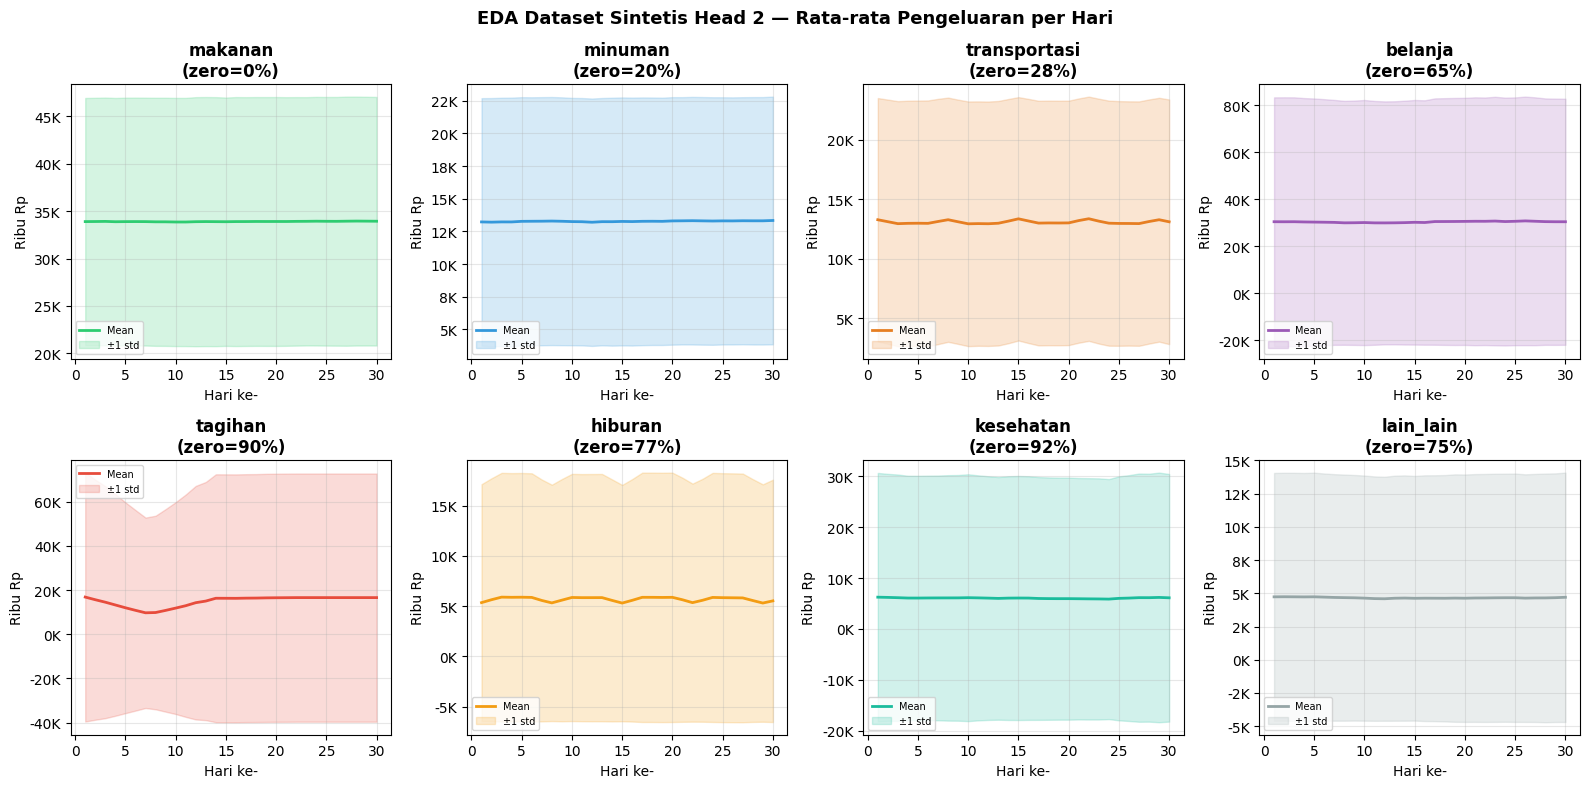

✅ Grafik EDA tersimpan: head2_eda.png


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, cat in enumerate(CATEGORIES):
    ax = axes[i]

    mean_per_day = X_h2[:, :, i].mean(axis=0)
    std_per_day  = X_h2[:, :, i].std(axis=0)
    days         = range(1, 31)

    ax.plot(days, mean_per_day, color=CAT_COLORS[cat], linewidth=2, label='Mean')
    ax.fill_between(days,
                    mean_per_day - std_per_day,
                    mean_per_day + std_per_day,
                    alpha=0.2, color=CAT_COLORS[cat], label='±1 std')

    zero_pct = (X_h2[:, :, i] == 0).mean() * 100
    ax.set_title(f"{cat}\n(zero={zero_pct:.0f}%)", fontweight='bold')
    ax.set_xlabel('Hari ke-')
    ax.set_ylabel('Ribu Rp')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0f}K'))

plt.suptitle('EDA Dataset Sintetis Head 2 — Rata-rata Pengeluaran per Hari',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('head2_eda.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Grafik EDA tersimpan: head2_eda.png")

## 🔧 Cell 5 — Preprocessing & Sliding Window

Sebelum data masuk ke model, ada dua langkah penting:

**1. Normalisasi dengan MinMaxScaler**
Nilai pengeluaran tiap kategori diubah ke skala 0-1.
Kenapa perlu? Karena nilai tagihan (bisa ratusan ribu) jauh lebih besar
dari kesehatan (puluhan ribu) — tanpa normalisasi, model akan "terlalu fokus"
ke kategori dengan nilai besar.

> ⚠️ Scaler di-fit **hanya dari data training (X)**, bukan dari y (target).
> Ini mencegah *data leakage* — model tidak boleh "tahu" tentang masa depan.

**2. Train / Val / Test Split (70 / 15 / 15)**
- **Train (70%)** → data untuk melatih model
- **Validation (15%)** → dipantau saat training untuk deteksi overfitting
- **Test (15%)** → evaluasi final, tidak disentuh selama training

**Output cell ini:**
- `X_train`, `X_val`, `X_test` → data input (normalized)
- `y_train`, `y_val`, `y_test` → data target (normalized)
- `scalers` → disimpan untuk inverse transform saat inference

In [ ]:
WINDOW_SIZE  = 30
PRED_HORIZON = 7

# ── Feature Engineering dari data mentah ─────────────────────────────
features = {}

for i, cat in enumerate(CATEGORIES):
    vals = X_h2[:, :, i]

    # Fitur statistik dasar
    features[f'mean_{cat}']          = vals.mean(axis=1)
    features[f'std_{cat}']           = vals.std(axis=1)
    features[f'max_{cat}']           = vals.max(axis=1)
    features[f'zero_pct_{cat}']      = (vals == 0).mean(axis=1)

    # Fitur tren: 7 hari terakhir vs 7 hari sebelumnya
    features[f'trend_{cat}']         = vals[:, -7:].mean(axis=1) - vals[:, -14:-7].mean(axis=1)

    # Rata-rata 7 hari terakhir
    features[f'mean7_last_{cat}']    = vals[:, -7:].mean(axis=1)

    # Deteksi spike (nilai > 2x rata-rata)
    mean_30 = vals.mean(axis=1)
    max_7   = vals[:, -7:].max(axis=1)
    features[f'spike_last7_{cat}']   = (max_7 > 2 * (mean_30 + 1e-8)).astype(np.float32)

    # Rasio akhir bulan vs awal bulan
    mean_awal  = vals[:, :10].mean(axis=1)
    mean_akhir = vals[:, -10:].mean(axis=1)
    features[f'rasio_akhir_awal_{cat}'] = np.where(
        mean_awal > 0, mean_akhir / (mean_awal + 1e-8), 0
    )

# Fitur total harian
total_per_hari = X_h2.sum(axis=2)
features['total_mean_30hari'] = total_per_hari.mean(axis=1)
features['total_std_30hari']  = total_per_hari.std(axis=1)
features['total_mean_7hari']  = total_per_hari[:, -7:].mean(axis=1)
features['total_trend']       = (total_per_hari[:, -7:].mean(axis=1) -
                                  total_per_hari[:, -14:-7].mean(axis=1))

df_features = pd.DataFrame(features)

# ── Normalisasi dengan MinMaxScaler ──────────────────────────────────
scalers  = {}
X_scaled = np.zeros_like(X_h2)
y_scaled = np.zeros_like(y_h2)

for i, cat in enumerate(CATEGORIES):
    scaler = MinMaxScaler(feature_range=(0, 1))
    X_flat = X_h2[:, :, i].reshape(-1, 1)
    scaler.fit(X_flat)
    X_scaled[:, :, i] = scaler.transform(X_flat).reshape(X_h2.shape[0], WINDOW_SIZE)
    y_scaled[:, :, i] = scaler.transform(
        y_h2[:, :, i].reshape(-1, 1)
    ).reshape(y_h2.shape[0], PRED_HORIZON)
    scalers[cat] = scaler

# ── Train / Val / Test split (70 / 15 / 15) ──────────────────────────
n   = len(X_scaled)
idx = np.random.RandomState(42).permutation(n)
n_tr  = int(n * 0.70)
n_val = int(n * 0.85)

idx_tr  = idx[:n_tr]
idx_val = idx[n_tr:n_val]
idx_te  = idx[n_val:]

X_train, y_train = X_scaled[idx_tr],  y_scaled[idx_tr]
X_val,   y_val   = X_scaled[idx_val], y_scaled[idx_val]
X_test,  y_test  = X_scaled[idx_te],  y_scaled[idx_te]
y_test_raw       = y_h2[idx_te]

print("✅ Feature engineering & preprocessing selesai!")
print(f"\nTotal fitur baru   : {len(df_features.columns)}")
print(f"Train  : {X_train.shape[0]:,} sampel")
print(f"Val    : {X_val.shape[0]:,} sampel")
print(f"Test   : {X_test.shape[0]:,} sampel")
print(f"\nCek zero% per kategori di y_test:")
for i, cat in enumerate(CATEGORIES):
    zero_pct = (y_test_raw[:, :, i] == 0).mean() * 100
    print(f"  {cat:<15}: zero={zero_pct:.1f}%")

✅ Feature engineering & preprocessing selesai!

Total fitur baru   : 68
Train  : 5,670 sampel
Val    : 1,215 sampel
Test   : 1,215 sampel

Cek zero% per kategori di y_test:
  makanan        : zero=0.0%
  minuman        : zero=20.4%
  transportasi   : zero=27.5%
  belanja        : zero=64.8%
  tagihan        : zero=90.2%
  hiburan        : zero=77.5%
  kesehatan      : zero=91.7%
  lain_lain      : zero=75.4%


## 🏗️ Cell 6 — Arsitektur Model MLP + GRU

Model dirancang khusus untuk menangkap **pola temporal pengeluaran** yang kompleks,
termasuk kategori sporadis seperti tagihan dan hiburan.

**Tiga komponen utama:**

**1. MLPEncoderLayer (TimeDistributed)**
Diterapkan ke setiap hari secara independen — mengubah 8 angka pengeluaran
per hari menjadi representasi fitur yang lebih kaya (64 → 32 dimensi).

**2. StackedGRULayer**
GRU (Gated Recurrent Unit) adalah model yang dirancang khusus untuk data urutan waktu.
- `GRU Layer 1` (64 units) → menangkap pola jangka menengah (1-2 minggu)
- `GRU Layer 2` (32 units) → memadatkan informasi menjadi satu vektor ringkasan

**3. MultiStepDecoderLayer**
Mengubah vektor ringkasan dari GRU menjadi prediksi 7 hari ke depan
untuk semua 8 kategori sekaligus.

**Mengapa pakai model subclassing (bukan Sequential)?**
Karena arsitektur ini lebih kompleks — ada custom layer, TimeDistributed,
dan struktur yang tidak bisa dibuat dengan cara sederhana.

> 💡 Total parameter model sekitar 50-100 ribu — cukup besar untuk
> menangkap pola kompleks, tapi tetap efisien untuk CPU Colab gratis.

In [ ]:
class MLPEncoderLayer(layers.Layer):
    def __init__(self, units=64, dropout=0.2, **kwargs):
        super().__init__(**kwargs)
        self.dense1  = layers.Dense(units, activation='relu')
        self.dense2  = layers.Dense(units // 2, activation='relu')
        self.drop    = layers.Dropout(dropout)
        self.bn      = layers.BatchNormalization()
        self.units   = units
        self.dropout = dropout

    def call(self, x, training=False):
        x = self.dense1(x)
        x = self.drop(x, training=training)
        x = self.dense2(x)
        return self.bn(x, training=training)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'units': self.units, 'dropout': self.dropout})
        return cfg


class StackedGRULayer(layers.Layer):
    def __init__(self, units_1=64, units_2=32, dropout=0.3, **kwargs):
        super().__init__(**kwargs)
        self.gru1    = layers.GRU(units_1, return_sequences=True,
                                   dropout=dropout, recurrent_dropout=0.1)
        self.gru2    = layers.GRU(units_2, return_sequences=False,
                                   dropout=dropout, recurrent_dropout=0.1)
        self.units_1 = units_1
        self.units_2 = units_2
        self.dropout = dropout

    def call(self, x, training=False):
        x = self.gru1(x, training=training)
        return self.gru2(x, training=training)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'units_1': self.units_1, 'units_2': self.units_2, 'dropout': self.dropout})
        return cfg


class MultiStepDecoderLayer(layers.Layer):
    def __init__(self, horizon, n_cats, units=128, **kwargs):
        super().__init__(**kwargs)
        self.horizon      = horizon
        self.n_cats       = n_cats
        self.dense1       = layers.Dense(units, activation='relu')
        self.dense2       = layers.Dense(units // 2, activation='relu')
        self.drop         = layers.Dropout(0.2)
        self.output_layer = layers.Dense(horizon * n_cats, activation='relu')
        self.reshape      = layers.Reshape((horizon, n_cats))

    def call(self, x, training=False):
        x = self.dense1(x)
        x = self.drop(x, training=training)
        x = self.dense2(x)
        x = self.output_layer(x)
        return self.reshape(x)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'horizon': self.horizon, 'n_cats': self.n_cats})
        return cfg


class CashFlowPredictor(Model):
    def __init__(self, window_size, pred_horizon, n_cats,
                 mlp_units=64, gru_units_1=64, gru_units_2=32,
                 decoder_units=128, **kwargs):
        super().__init__(**kwargs)
        self.window_size  = window_size
        self.pred_horizon = pred_horizon
        self.n_cats       = n_cats
        self.td_mlp       = layers.TimeDistributed(
            MLPEncoderLayer(mlp_units, dropout=0.2), name='mlp_encoder')
        self.stacked_gru  = StackedGRULayer(gru_units_1, gru_units_2,
                                             dropout=0.3, name='stacked_gru')
        self.decoder      = MultiStepDecoderLayer(pred_horizon, n_cats,
                                                   decoder_units, name='multi_step_decoder')

    def call(self, x, training=False):
        x = self.td_mlp(x, training=training)
        x = self.stacked_gru(x, training=training)
        return self.decoder(x, training=training)

    def get_config(self):
        return {'window_size': self.window_size,
                'pred_horizon': self.pred_horizon,
                'n_cats': self.n_cats}


# Build model
model_head2 = CashFlowPredictor(
    window_size=WINDOW_SIZE, pred_horizon=PRED_HORIZON,
    n_cats=N_CATS, mlp_units=64, gru_units_1=64,
    gru_units_2=32, decoder_units=128, name="CashFlowPredictor"
)
_ = model_head2(tf.zeros((1, WINDOW_SIZE, N_CATS)))

n_params = sum(tf.size(v).numpy() for v in model_head2.trainable_variables)
print("✅ Model CashFlowPredictor siap!")
print(f"   Trainable params : {n_params:,}")
print(f"   Input shape      : (batch, {WINDOW_SIZE}, {N_CATS})")
print(f"   Output shape     : (batch, {PRED_HORIZON}, {N_CATS})")
print("\nArsitektur:")
print("   TimeDistributed(MLPEncoder) → StackedGRU(64→32) → MultiStepDecoder")

✅ Model CashFlowPredictor siap!
   Trainable params : 47,064
   Input shape      : (batch, 30, 8)
   Output shape     : (batch, 7, 8)

Arsitektur:
   TimeDistributed(MLPEncoder) → StackedGRU(64→32) → MultiStepDecoder


## 🚀 Cell 7 — Custom Loss & Training Loop

Ini adalah cell terpanjang dan terpenting. Ada beberapa teknik canggih di sini:

**1. SporadicAwareLoss (Custom Loss)**
Loss standar (MAE/MSE) tidak cocok karena kategori seperti tagihan dan kesehatan
**kebanyakan bernilai 0** — model bisa dapat loss kecil hanya dengan selalu prediksi 0!
Custom loss ini memberi **penalti ekstra (5×)** saat model gagal mendeteksi spike.

**2. WarmupExponentialDecay (Learning Rate Schedule)**
- Fase **warmup** (awal training) → learning rate naik perlahan agar tidak overshoot
- Fase **decay** (pertengahan-akhir) → learning rate turun agar model fine-tune

**3. Oversampling Sampel dengan Spike**
Sampel yang mengandung tagihan/hiburan/kesehatan/belanja besar
**dikopi 3× lebih banyak** ke dataset training agar model lebih sering belajar
dari kasus-kasus yang sulit.

**4. Early Stopping (Patience=12)**
Jika val_loss tidak turun selama 12 epoch berturut-turut, training berhenti otomatis
dan bobot terbaik dikembalikan — mencegah overfitting.

**5. Gradient Clipping**
Membatasi nilai gradien agar training tidak "meledak" (exploding gradients).

> ⏳ Training ~60 epoch di CPU Colab memakan waktu **20-40 menit**.
> Biarkan berjalan, jangan tutup tab Colab!

Sampel setelah augmentasi: 22,680
TRAINING Head 2 — SporadicAwareLoss + Oversampling
Epochs=60 | Batch=64 | LR=0.0005 | Patience=12
------------------------------------------------------------
Epoch  1/60 | loss=0.7141 val=0.4613 | mae=0.1490 val_mae=0.1132 | 44.6s
  → Best val_loss=0.4613 ✅
Epoch  2/60 | loss=0.3913 val=0.3820 | mae=0.1013 val_mae=0.0952 | 20.2s
  → Best val_loss=0.3820 ✅
Epoch  3/60 | loss=0.3623 val=0.3651 | mae=0.0961 val_mae=0.0960 | 19.4s
  → Best val_loss=0.3651 ✅
Epoch  4/60 | loss=0.3464 val=0.3560 | mae=0.0957 val_mae=0.0960 | 20.6s
  → Best val_loss=0.3560 ✅
Epoch  5/60 | loss=0.3415 val=0.3644 | mae=0.0952 val_mae=0.0966 | 21.7s
Epoch  6/60 | loss=0.3393 val=0.3408 | mae=0.0949 val_mae=0.0982 | 26.4s
  → Best val_loss=0.3408 ✅
Epoch  7/60 | loss=0.3381 val=0.3404 | mae=0.0947 val_mae=0.0958 | 21.6s
  → Best val_loss=0.3404 ✅
Epoch  8/60 | loss=0.3368 val=0.3532 | mae=0.0945 val_mae=0.0970 | 20.4s
Epoch  9/60 | loss=0.3364 val=0.3251 | mae=0.0944 val_mae=0.0

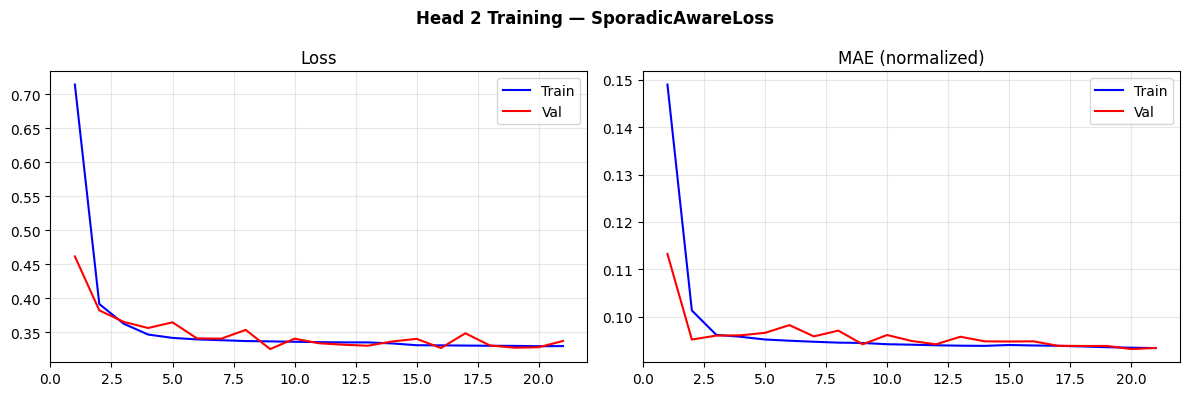


✅ Training selesai! Best val_loss=0.3251


In [ ]:
# ── Custom Loss ───────────────────────────────────────────────────────
class SporadicAwareLoss(tf.keras.losses.Loss):
    def __init__(self, category_weights=None, spike_penalty=5.0, **kwargs):
        super().__init__(**kwargs)
        if category_weights is None:
            category_weights = [1.0] * 8
        self.weights       = tf.constant(category_weights, dtype=tf.float32)
        self.spike_penalty = spike_penalty

    def call(self, y_true, y_pred):
        mae       = tf.abs(y_true - y_pred)
        weighted  = mae * self.weights
        threshold = 0.05
        is_spike  = tf.cast(y_true > threshold, tf.float32)
        is_miss   = tf.cast(y_pred < threshold, tf.float32)
        penalty   = is_spike * is_miss * tf.abs(y_true - y_pred) * self.spike_penalty
        return tf.reduce_mean(weighted + penalty)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'category_weights': self.weights.numpy().tolist(),
                    'spike_penalty': self.spike_penalty})
        return cfg


# ── Learning Rate Schedule ────────────────────────────────────────────
class WarmupExponentialDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr, warmup_steps, decay_steps, decay_rate):
        super().__init__()
        self.base_lr      = base_lr
        self.warmup_steps = float(warmup_steps)
        self.decay_steps  = float(decay_steps)
        self.decay_rate   = decay_rate

    def __call__(self, step):
        step   = tf.cast(step, tf.float32)
        warmup = step / self.warmup_steps * self.base_lr
        decay  = self.base_lr * tf.pow(self.decay_rate,
                  (step - self.warmup_steps) / self.decay_steps)
        return tf.where(step < self.warmup_steps, warmup, decay)

    def get_config(self):
        return {'base_lr': self.base_lr, 'warmup_steps': self.warmup_steps,
                'decay_steps': self.decay_steps, 'decay_rate': self.decay_rate}


# ── Hyperparameter ────────────────────────────────────────────────────
EPOCHS     = 60
BATCH_SIZE = 64
BASE_LR    = 5e-4
PATIENCE   = 12
GRAD_CLIP  = 1.0

category_weights = [2.0, 1.5, 1.5, 3.0, 4.0, 3.0, 3.0, 1.5]

# ── Oversampling sampel dengan spike ─────────────────────────────────
spike_cats = [CATEGORIES.index(c) for c in ['tagihan', 'hiburan', 'kesehatan', 'belanja']]
has_spike  = np.zeros(len(X_train), dtype=bool)
for cat_i in spike_cats:
    has_spike |= (X_train[:, :, cat_i].max(axis=1) > 0.05)

spike_idx   = np.where(has_spike)[0]
X_train_aug = np.concatenate([X_train] + [X_train[spike_idx]] * 3, axis=0)
y_train_aug = np.concatenate([y_train] + [y_train[spike_idx]] * 3, axis=0)

aug_idx     = np.random.RandomState(42).permutation(len(X_train_aug))
X_train_aug = X_train_aug[aug_idx]
y_train_aug = y_train_aug[aug_idx]
print(f"Sampel setelah augmentasi: {len(X_train_aug):,}")

# ── Reset & build model ───────────────────────────────────────────────
model_head2 = CashFlowPredictor(
    window_size=WINDOW_SIZE, pred_horizon=PRED_HORIZON, n_cats=N_CATS)
_ = model_head2(tf.zeros((1, WINDOW_SIZE, N_CATS)))

total_steps  = (len(X_train_aug) // BATCH_SIZE) * EPOCHS
warmup_steps = total_steps // 10

optimizer = tf.keras.optimizers.Adam(
    learning_rate=WarmupExponentialDecay(
        BASE_LR, warmup_steps, total_steps // 2, 0.5))
loss_fn = SporadicAwareLoss(category_weights=category_weights, spike_penalty=5.0)

# ── Dataset ───────────────────────────────────────────────────────────
train_ds = (tf.data.Dataset
    .from_tensor_slices((X_train_aug, y_train_aug))
    .shuffle(len(X_train_aug), seed=42)
    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

val_ds = (tf.data.Dataset
    .from_tensor_slices((X_val, y_val))
    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

# ── Training loop ─────────────────────────────────────────────────────
@tf.function
def train_step(x_batch, y_batch):
    with tf.GradientTape() as tape:
        y_pred     = model_head2(x_batch, training=True)
        loss       = loss_fn(y_batch, y_pred)
        l2         = tf.add_n([tf.nn.l2_loss(v)
                               for v in model_head2.trainable_variables
                               if 'kernel' in v.name]) * 1e-5
        total_loss = loss + l2
    grads = tape.gradient(total_loss, model_head2.trainable_variables)
    grads, _ = tf.clip_by_global_norm(grads, GRAD_CLIP)
    optimizer.apply_gradients(zip(grads, model_head2.trainable_variables))
    return total_loss, y_pred

@tf.function
def val_step(x_batch, y_batch):
    y_pred = model_head2(x_batch, training=False)
    loss   = loss_fn(y_batch, y_pred)
    return loss, y_pred

print("=" * 60)
print("TRAINING Head 2 — SporadicAwareLoss + Oversampling")
print("=" * 60)
print(f"Epochs={EPOCHS} | Batch={BATCH_SIZE} | LR={BASE_LR} | Patience={PATIENCE}")
print("-" * 60)

history        = {'train_loss': [], 'val_loss': [], 'train_mae': [], 'val_mae': []}
best_val_loss  = float('inf')
best_weights   = None
patience_count = 0

for epoch in range(EPOCHS):
    t0 = time.time()

    tr_losses, tr_preds, tr_true = [], [], []
    for xb, yb in train_ds:
        loss, pred = train_step(xb, yb)
        tr_losses.append(loss.numpy())
        tr_preds.append(pred.numpy())
        tr_true.append(yb.numpy())

    tr_loss = np.mean(tr_losses)
    tr_mae  = np.mean(np.abs(np.concatenate(tr_preds) - np.concatenate(tr_true)))

    vl_losses, vl_preds, vl_true = [], [], []
    for xb, yb in val_ds:
        loss, pred = val_step(xb, yb)
        vl_losses.append(loss.numpy())
        vl_preds.append(pred.numpy())
        vl_true.append(yb.numpy())

    vl_loss = np.mean(vl_losses)
    vl_mae  = np.mean(np.abs(np.concatenate(vl_preds) - np.concatenate(vl_true)))

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_mae'].append(tr_mae)
    history['val_mae'].append(vl_mae)

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | loss={tr_loss:.4f} val={vl_loss:.4f} | "
          f"mae={tr_mae:.4f} val_mae={vl_mae:.4f} | {time.time()-t0:.1f}s")

    if vl_loss < best_val_loss:
        best_val_loss  = vl_loss
        best_weights   = [v.numpy() for v in model_head2.trainable_variables]
        patience_count = 0
        print(f"  → Best val_loss={best_val_loss:.4f} ✅")
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"Early stopping epoch {epoch+1}")
            break

if best_weights:
    for v, w in zip(model_head2.trainable_variables, best_weights):
        v.assign(w)

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, len(history['train_loss']) + 1)
ax1.plot(ep, history['train_loss'], 'b-', label='Train')
ax1.plot(ep, history['val_loss'],   'r-', label='Val')
ax1.set_title('Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(ep, history['train_mae'], 'b-', label='Train')
ax2.plot(ep, history['val_mae'],   'r-', label='Val')
ax2.set_title('MAE (normalized)'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.suptitle('Head 2 Training — SporadicAwareLoss', fontweight='bold')
plt.tight_layout()
plt.savefig('head2_training.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"\n✅ Training selesai! Best val_loss={best_val_loss:.4f}")

## 📈 Cell 8 — Evaluasi Model

Setelah training selesai, kita ukur seberapa baik model bisa memprediksi
pengeluaran 7 hari ke depan pada data test (yang belum pernah dilihat model).

**Metrik yang digunakan:**

| Metrik | Penjelasan | Satuan |
|--------|------------|--------|
| **MAE** | Rata-rata selisih absolut prediksi vs aktual | Ribu Rp |
| **RMSE** | Seperti MAE tapi memberi penalti lebih besar untuk error besar | Ribu Rp |
| **MAPE** | Error dalam persentase (hanya dihitung saat aktual > 0) | % |
| **Zero GT%** | Berapa % hari yang memang tidak ada pengeluaran | % |

**Cara membaca hasil:**
- MAE kecil = prediksi akurat
- Zero GT% tinggi (misal tagihan 90%) = wajar kalau MAPE besar
  karena sebagian besar hari memang 0 dan tidak masuk perhitungan MAPE

**Visualisasi yang dihasilkan:**
1. Prediksi vs Aktual untuk 1 sampel terpilih (yang punya pengeluaran di semua kategori)
2. Rata-rata prediksi vs aktual untuk semua sampel test

EVALUASI Head 2 — Test Set (satuan: ribuan Rupiah)
Kategori          MAE (rb)  RMSE (rb)   MAPE (%)   Zero GT%
----------------------------------------------------------
makanan               5.9K       7.2K      17.6%       0.0%
minuman               6.6K       8.5K      27.6%      20.4%
transportasi          7.3K       9.4K      24.9%      27.5%
belanja              33.7K      55.0K      77.4%      64.8%
tagihan              13.2K      51.6K     100.0%      90.2%
hiburan               5.5K      13.2K     100.0%      77.5%
kesehatan             6.1K      24.7K     100.0%      91.7%
lain_lain             5.8K       9.4K      82.6%      75.4%
----------------------------------------------------------
OVERALL              10.5K


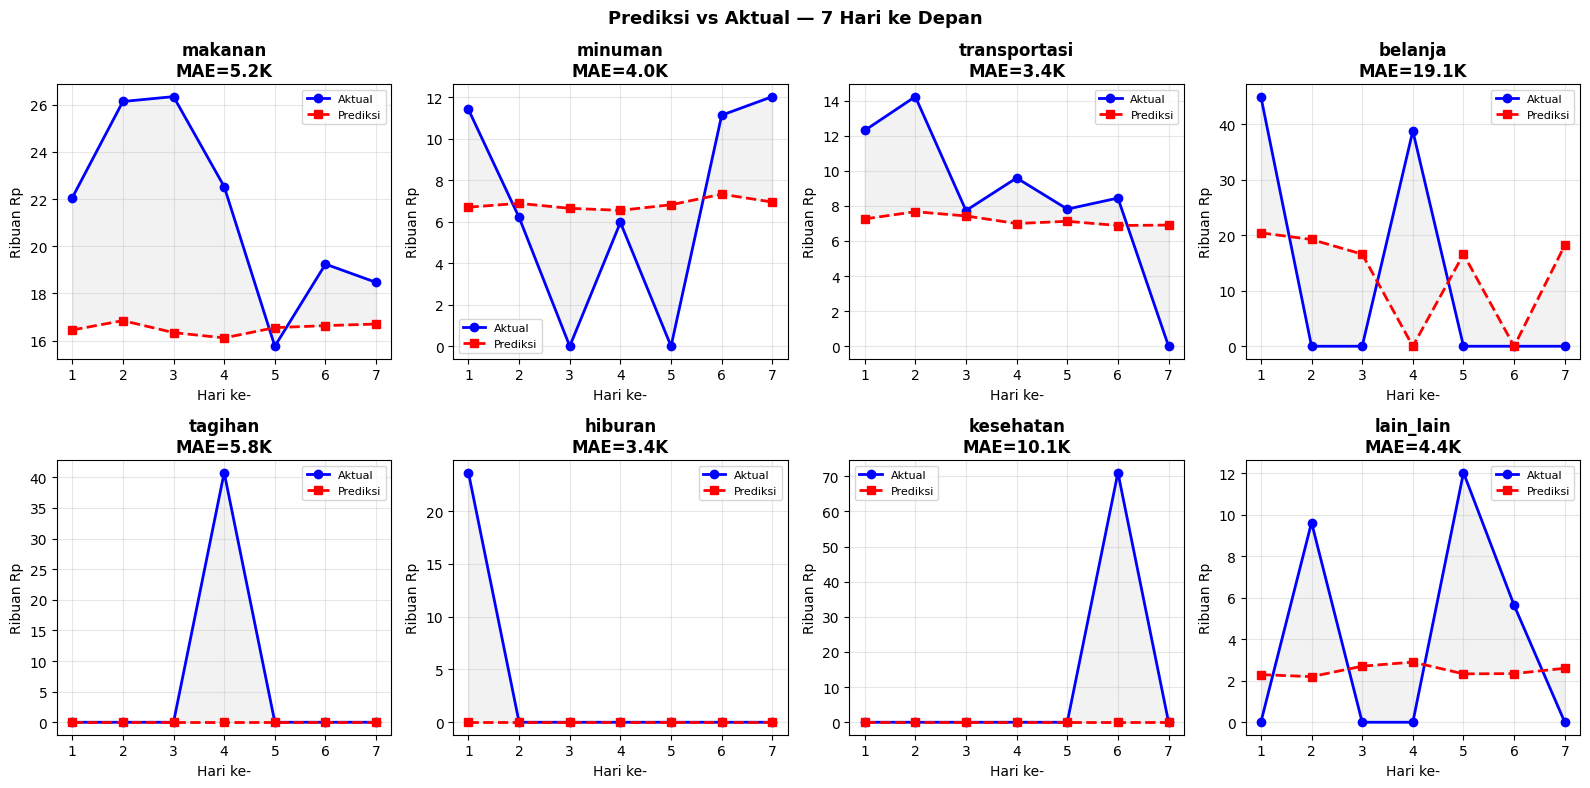

✅ Evaluasi selesai! Grafik tersimpan: head2_evaluation.png


In [ ]:
# Prediksi pada test set
y_pred_scaled = model_head2.predict(X_test, batch_size=64, verbose=0)

# Inverse transform ke satuan Rupiah
y_pred_raw = np.zeros_like(y_pred_scaled)
for i, cat in enumerate(CATEGORIES):
    y_pred_raw[:, :, i] = scalers[cat].inverse_transform(
        y_pred_scaled[:, :, i].reshape(-1, 1)
    ).reshape(y_pred_scaled.shape[0], PRED_HORIZON)

y_pred_raw = np.clip(y_pred_raw, 0, None)
y_true_raw = y_h2[idx_te]

# Metrik per kategori
print("=" * 65)
print("EVALUASI Head 2 — Test Set (satuan: ribuan Rupiah)")
print("=" * 65)
print(f"{'Kategori':<15} {'MAE (rb)':>10} {'RMSE (rb)':>10} {'MAPE (%)':>10} {'Zero GT%':>10}")
print("-" * 58)

for i, cat in enumerate(CATEGORIES):
    true = y_true_raw[:, :, i].flatten()
    pred = y_pred_raw[:, :, i].flatten()
    mae  = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    mask = true > 0
    mape = (np.mean(np.abs((true[mask] - pred[mask]) / true[mask])) * 100
            if mask.sum() > 0 else float('nan'))
    zero_gt = (true == 0).mean() * 100
    print(f"{cat:<15} {mae:>9.1f}K {rmse:>9.1f}K {mape:>9.1f}% {zero_gt:>9.1f}%")

print("-" * 58)
total_mae = mean_absolute_error(y_true_raw.flatten(), y_pred_raw.flatten())
print(f"{'OVERALL':<15} {total_mae:>9.1f}K")

# Visualisasi prediksi vs aktual
best_idx      = max(range(min(200, len(y_true_raw))),
                     key=lambda idx: sum(y_true_raw[idx, :, i].sum() > 0
                                         for i in range(N_CATS)))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, cat in enumerate(CATEGORIES):
    ax   = axes[i]
    true = y_true_raw[best_idx, :, i]
    pred = y_pred_raw[best_idx, :, i]
    days = range(1, PRED_HORIZON + 1)

    ax.plot(days, true,  'b-o',  label='Aktual',   linewidth=2, markersize=6)
    ax.plot(days, pred,  'r--s', label='Prediksi', linewidth=2, markersize=6)
    ax.fill_between(days, true, pred, alpha=0.1, color='gray')
    mae_sample = mean_absolute_error(true, pred)
    ax.set_title(f"{cat}\nMAE={mae_sample:.1f}K", fontweight='bold')
    ax.set_xlabel('Hari ke-')
    ax.set_ylabel('Ribuan Rp')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Prediksi vs Aktual — 7 Hari ke Depan', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('head2_evaluation.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Evaluasi selesai! Grafik tersimpan: head2_evaluation.png")

## 💾 Cell 9 — Simpan Model ke Google Drive

Model yang sudah dilatih perlu disimpan agar bisa dipakai ulang
tanpa harus training dari awal setiap kali.

**3 file yang disimpan:**

| File | Isi | Kegunaan |
|------|-----|----------|
| `head2.weights.h5` | Bobot (parameter) model | Untuk load model dan inference |
| `head2_scalers.pkl` | MinMaxScaler per kategori | Untuk normalisasi data baru saat inference |
| `head2_config.json` | Konfigurasi model (ukuran, kategori, dll) | Untuk rebuild arsitektur model |

**Lokasi penyimpanan:** `Google Drive/LaporKeuangan/Head2/`

> 📌 Pastikan kamu login ke Google Drive yang sama saat
> akan menggunakan model ini di notebook lain (misalnya integrasi ke API).

In [ ]:
import pickle

try:
    from google.colab import drive
    drive.mount('/content/drive')

    save_dir = '/content/drive/MyDrive/LaporKeuangan/Head2'
    os.makedirs(save_dir, exist_ok=True)

    # Simpan weights model
    model_head2.save_weights(f'{save_dir}/head2.weights.h5')

    # Simpan scalers
    with open(f'{save_dir}/head2_scalers.pkl', 'wb') as f:
        pickle.dump(scalers, f)

    # Simpan config
    config = {
        'window_size'  : WINDOW_SIZE,
        'pred_horizon' : PRED_HORIZON,
        'n_cats'       : N_CATS,
        'categories'   : CATEGORIES,
        'best_val_loss': float(best_val_loss),
    }
    with open(f'{save_dir}/head2_config.json', 'w') as f:
        json.dump(config, f, indent=2, ensure_ascii=False)

    # Simpan juga fitur engineering ke Drive
    df_features.to_csv(f'{save_dir}/head2_features_engineered.csv', index=False)

    print(f"✅ Semua file tersimpan di: {save_dir}")
    print("   head2.weights.h5")
    print("   head2_scalers.pkl")
    print("   head2_config.json")
    print("   head2_features_engineered.csv")

except Exception as e:
    print(f"⚠️ Gagal simpan ke Drive: {e}")
    print("   Model tersimpan di memory session ini.")

Mounted at /content/drive
✅ Semua file tersimpan di: /content/drive/MyDrive/LaporKeuangan/Head2
   head2.weights.h5
   head2_scalers.pkl
   head2_config.json
   head2_features_engineered.csv


## 🎯 Cell 10 — Inference: Prediksi 7 Hari ke Depan

Cell terakhir ini menunjukkan bagaimana model digunakan dalam kondisi nyata
di aplikasi SnapBudget.

**Fungsi `predict_cashflow()`** menerima:
- `riwayat_df` → DataFrame dengan riwayat 30 hari pengeluaran per kategori
- `user_id` → untuk filter jika data berisi banyak user

**Alur inference:**
1. Ambil 30 hari terakhir dari riwayat user
2. Normalisasi menggunakan scaler yang sama saat training
3. Masukkan ke model → dapat prediksi 7 hari (dalam skala 0-1)
4. Inverse transform → konversi balik ke Rupiah
5. Susun hasil per hari dan per kategori

**Output yang dihasilkan:**
- Prediksi pengeluaran per kategori per hari (7 hari)
- Total prediksi 7 hari
- Rata-rata pengeluaran per hari
- Visualisasi stacked bar + pie chart distribusi

> 💡 Output dari Head 2 ini akan menjadi **input untuk Head 3**
> (rekomendasi status keuangan). Pastikan format outputnya sesuai.

DEMO — Prediksi 7 Hari ke Depan

Kategori         Daily avg  Pred/hari     Sumber
--------------------------------------------------
makanan              35.0K      22.8K      model
minuman              13.3K       9.7K      model
transportasi         13.0K      10.3K      model
belanja              10.0K      12.7K      model
tagihan               6.7K       0.0K   fallback
hiburan               3.3K       0.0K   fallback
kesehatan             2.0K       0.0K   fallback
lain_lain             3.0K       2.5K      model
--------------------------------------------------
Total prediksi 7 hari: Rp 477.772


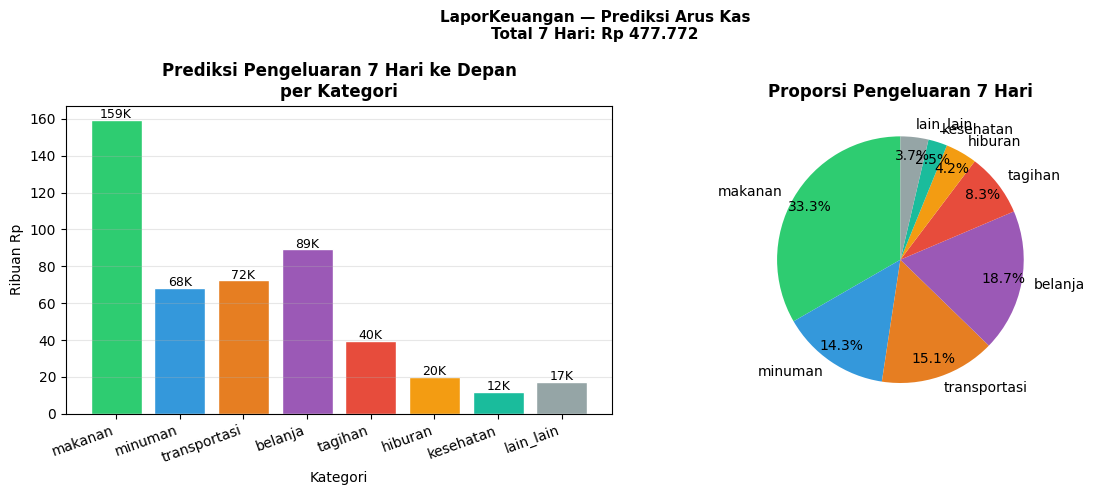


✅ Output prediksi (format untuk Head 3):
{
  "makanan": 159253,
  "minuman": 68141,
  "transportasi": 72331,
  "belanja": 89170,
  "tagihan": 39667,
  "hiburan": 19833,
  "kesehatan": 11900,
  "lain_lain": 17477
}


In [ ]:
def predict_cashflow_7hari(actual_dict, day_of_month=15):
    """
    Prediksi pengeluaran 7 hari ke depan dari data aktual bulan ini.

    Args:
        actual_dict  : {kategori: total_rupiah_bulan_ini}
                       contoh: {'makanan': 525000, 'tagihan': 100000}
        day_of_month : hari ke berapa dalam bulan (default: 15)

    Returns:
        dict prediksi per kategori (dalam Rupiah)
    """
    days_elapsed = max(1, day_of_month)

    # Konversi ke ribuan Rp
    actual_rb = {cat: val / 1000 for cat, val in actual_dict.items()}

    # Buat input sequence 30 hari dari rata-rata harian
    x_input = np.zeros((1, WINDOW_SIZE, N_CATS), dtype=np.float32)
    rng     = np.random.RandomState(42)

    for i, cat in enumerate(CATEGORIES):
        daily_avg_rb = actual_rb.get(cat, 0) / days_elapsed
        seq = np.array([
            max(0, daily_avg_rb * (1 + rng.normal(0, 0.12)))
            for _ in range(WINDOW_SIZE)
        ], dtype=np.float32)
        x_input[0, :, i] = scalers[cat].transform(seq.reshape(-1, 1)).flatten()

    # Prediksi
    pred_scaled = model_head2(x_input, training=False).numpy()[0]

    # Inverse transform
    pred_rb = np.zeros((PRED_HORIZON, N_CATS), dtype=np.float32)
    for i, cat in enumerate(CATEGORIES):
        raw = scalers[cat].inverse_transform(
            pred_scaled[:, i].reshape(-1, 1)
        ).flatten()
        pred_rb[:, i] = np.clip(raw, 0, None)

    # Fallback untuk kategori yang under-prediksi
    FALLBACK_THRESHOLD = 0.15
    pred_7d = {}

    print(f"\n{'Kategori':<15} {'Daily avg':>10} {'Pred/hari':>10} {'Sumber':>10}")
    print("-" * 50)

    for i, cat in enumerate(CATEGORIES):
        daily_avg_rb  = actual_rb.get(cat, 0) / days_elapsed
        pred_total_rb = float(pred_rb[:, i].sum())
        pred_daily_rb = pred_total_rb / PRED_HORIZON
        expected_7d   = daily_avg_rb * PRED_HORIZON

        if (expected_7d > 0 and pred_total_rb < expected_7d * FALLBACK_THRESHOLD):
            pred_7d[cat] = round(daily_avg_rb * PRED_HORIZON * 0.85 * 1000)
            sumber = "fallback"
        else:
            pred_7d[cat] = round(pred_total_rb * 1000)
            sumber = "model"

        print(f"{cat:<15} {daily_avg_rb:>9.1f}K {pred_daily_rb:>9.1f}K {sumber:>10}")

    print("-" * 50)
    total = sum(pred_7d.values())
    print(f"Total prediksi 7 hari: Rp {total:,}".replace(',', '.'))

    return pred_7d


# ── Demo inference ────────────────────────────────────────────────────
print("=" * 55)
print("DEMO — Prediksi 7 Hari ke Depan")
print("=" * 55)

aktual_demo = {
    'makanan'      : 525_000,
    'minuman'      : 200_000,
    'transportasi' : 195_000,
    'belanja'      : 150_000,
    'tagihan'      : 100_000,
    'hiburan'      :  50_000,
    'kesehatan'    :  30_000,
    'lain_lain'    :  45_000,
}

hasil_prediksi = predict_cashflow_7hari(aktual_demo, day_of_month=15)

# Visualisasi prediksi
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart per kategori
cats  = list(hasil_prediksi.keys())
vals  = [v / 1000 for v in hasil_prediksi.values()]
colors = [CAT_COLORS[c] for c in cats]
bars  = ax1.bar(cats, vals, color=colors, edgecolor='white')
ax1.set_title('Prediksi Pengeluaran 7 Hari ke Depan\nper Kategori',
              fontweight='bold')
ax1.set_xlabel('Kategori')
ax1.set_ylabel('Ribuan Rp')
ax1.set_xticklabels(cats, rotation=20, ha='right')
ax1.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.0f}K', ha='center', fontsize=9)

# Pie chart proporsi
mask   = [v > 0 for v in vals]
labels = [c for c, m in zip(cats, mask) if m]
values = [v for v, m in zip(vals, mask) if m]
clrs   = [CAT_COLORS[c] for c, m in zip(cats, mask) if m]
ax2.pie(values, labels=labels, colors=clrs,
        autopct='%1.1f%%', startangle=90, pctdistance=0.85)
ax2.set_title('Proporsi Pengeluaran 7 Hari', fontweight='bold')

total = sum(hasil_prediksi.values())
plt.suptitle(f'LaporKeuangan — Prediksi Arus Kas\n'
             f'Total 7 Hari: Rp {total:,}'.replace(',', '.'),
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('head2_prediction.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✅ Output prediksi (format untuk Head 3):")
print(json.dumps({k: v for k, v in hasil_prediksi.items()}, indent=2, ensure_ascii=False))